#### EXAMPLE

| Size (sqft) | Number of Bedrooms  | Number of floors | Age of  Home | Price (1000s dollars)  |   
| ----------------| ------------------- |----------------- |--------------|-------------- |  
| 2104            | 5                   | 1                | 45           | 460           |  
| 1416            | 3                   | 2                | 40           | 232           |  
| 852             | 2                   | 1                | 35           | 178           |  

You will build a linear regression model using these values so you can then predict the price for other houses.<br/>
For example, a house with 1200 sqft, 3 bedrooms, 1 floor, 40 years old.

In [17]:
import numpy as np
import matplotlib.pyplot as plt

import math, copy

# setting costum styles and colours for plot
plt.style.use("util/deeplearning.mplstyle")

# reduce the display precision of numpy arrays
np.set_printoptions(precision = 2)


x_train = np.array([
        [2104, 5, 1, 45], 
        [1416, 3, 2, 40], 
        [852, 2, 1, 35]
    ])
y_train = np.array([460, 232, 178])


# consider some initial values for bias & weights
w = np.array( [0.39133535, 18.75376741, -53.36032453, -26.42131618] )
b = 785.1811367994083

### Model Prediction with multiple variables

The model's prediction with multiple variables is given by the linear model:

$$ f_{\mathbf{w},b}(\mathbf{x}) =  w_0x_0 + w_1x_1 +... + w_{n-1}x_{n-1} + b \tag{1}$$
or in vector notation using `dot product`:
$$ f_{\mathbf{w},b}(\mathbf{x}) = \mathbf{w} \cdot \mathbf{x} + b  \tag{2} $$ 

In [22]:
# calculate f_wb (prediction) using dot product
f_wb_0 = np.dot(x_train[0], w) + b
f_wb_1 = np.dot(x_train[1], w) + b

print(f_wb_0, f_wb_1)

459.9999976194083 231.9999983694081


#### Compute Cost with multiple variables

The equation for the cost function with multiple variables $J(\mathbf{w},b)$ is:
$$J(\mathbf{w},b) = \frac{1}{2m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})^2 \tag{3}$$ 
where:
$$ f_{\mathbf{w},b}(\mathbf{x}^{(i)}) = \mathbf{w} \cdot \mathbf{x}^{(i)} + b  \tag{4} $$ 


$\mathbf{w}$ and $\mathbf{x}^{(i)}$ are vectors rather than scalars supporting multiple features.

In [37]:
def compute_cost(x_train:np.array, y_train:np.array, w:np.array, b:float)->float:
    m = x_train.shape[0]             # no of examples

    j_wb = 0

    for i, x in enumerate(x_train):
        f_wb = np.dot(x, w) + b   # compute prediction
        error = f_wb - y_train[i]    # compute error (diff b/w prediction and output
        j_wb += (error ** 2)         # update cost function summation

    j_wb /= (2 * m)
    return j_wb


cost_j = compute_cost(x_train, y_train, w, b)
print(cost_j)

1.5578904428966628e-12


#### Gradient Descent with multiple variables

Gradient descent for multiple variables:

$$\begin{align*} \text{repeat}&\text{ until convergence:} \; \lbrace \newline\;
& w_j = w_j -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial w_j} \tag{5}  \; & \text{for j = 0..n-1}\newline
&b\ \ = b -  \alpha \frac{\partial J(\mathbf{w},b)}{\partial b}  \newline \rbrace
\end{align*}$$

where, n is the number of features, parameters $w_j$,  $b$, are updated simultaneously and where  

$$
\begin{align}
\frac{\partial J(\mathbf{w},b)}{\partial w_j}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)})x_{j}^{(i)} \tag{6}  \\
\frac{\partial J(\mathbf{w},b)}{\partial b}  &= \frac{1}{m} \sum\limits_{i = 0}^{m-1} (f_{\mathbf{w},b}(\mathbf{x}^{(i)}) - y^{(i)}) \tag{7}
\end{align}
$$
* m is the number of training examples in the data set

    
*  $f_{\mathbf{w},b}(\mathbf{x}^{(i)})$ is the model's prediction, while $y^{(i)}$ is the target value


In [38]:
# let's calculate the gradient first
def compute_gradient(x_train:np.array, y_train:np.array, w:np.array, b:float) -> tuple(np.array, float):
    m, n = x_train.shape   # m - no of examples (rows), n - no of features (columns)

    dj_dw = np.zeros(n)    # contains -> [dj_dw0, dj_dw1, dj_dw2.... dj_dwn]
    dj_db = 0

    for i, x in enumerate(x_train):
        f_wb = np.dot(x, w) + b      # compute prediction
        error = f_wb - y_train[i]    # compute error (diff b/w prediction and output

        # summation for individual weights
        for j in range(n):
            dj_dw[j] += error * x_train[i][j]

        # summation for bias
        dj_db += error

    dj_dw /= m       # each element in array is divided by m
    dj_db /= m

    return dj_dw, dj_db


# testing
dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)
print(f"dj_dw = {dj_dw},\ndj_db = {dj_db}")

dj_dw = [-2.73e-03 -6.27e-06 -2.22e-06 -6.92e-05],
dj_db = -1.6739251501955248e-06


In [42]:
# now let's do the gradient descent algorithm
def gradient_descent(x_train:np.array, y_train:np.array, w_init:np.array, b_init:float, alpha:float, iteration:int):
    j_history = []    # record the cost function value (for graphing)

    # let's take copy of w_init & b_init (we will modify this in the loop)
    w = copy.deepcopy(w_init)
    b = b_init
    
    for i in range(iteration):
        # calculate the gradient
        dj_dw, dj_db = compute_gradient(x_train, y_train, w, b)

        # update w and b
        w = w - alpha * dj_dw      # each value in the array is updated
        b = b - alpha * dj_db

        # calculate cost function, just for graphing purpose only
        j_history.append(compute_cost(x_train, y_train, w, b))

        # print value at every interval of 10
        if i% math.ceil(iteration / 10) == 0:
            print(f"interation {i:4d} | cost {j_history[-1]:8.2f} | weights {w} | bias {b:8.2f}")

    return w, b, j_history


# testing
w_init = np.zeros_like(w)
b_init = 0
iteration = 1000
alpha = 5.0E-7

w_final, b_final, j_history = gradient_descent(x_train, y_train, w_init, b_init, alpha, iteration)
print(f"\nw -> {w_final}, b -> {b_final:0.2f}\n")

# for this identified w and b values, let's see how close 
# the prediction and the target values are
for i, x in enumerate(x_train):
    prediction = np.dot(w_final, x) + b_final
    print(f"target: {y_train[i]} | prediction: {prediction:0.2f}")

interation    0 | cost  2529.46 | weights [2.41e-01 5.59e-04 1.84e-04 6.03e-03] | bias     0.00
interation  100 | cost   695.99 | weights [ 0.2  0.  -0.  -0. ] | bias    -0.00
interation  200 | cost   694.92 | weights [ 0.2   0.   -0.   -0.01] | bias    -0.00
interation  300 | cost   693.86 | weights [ 0.2   0.   -0.   -0.02] | bias    -0.00
interation  400 | cost   692.81 | weights [ 0.2   0.   -0.   -0.02] | bias    -0.00
interation  500 | cost   691.77 | weights [ 0.2   0.   -0.01 -0.03] | bias    -0.00
interation  600 | cost   690.73 | weights [ 0.2   0.   -0.01 -0.04] | bias    -0.00
interation  700 | cost   689.71 | weights [ 0.2   0.   -0.01 -0.04] | bias    -0.00
interation  800 | cost   688.70 | weights [ 0.2   0.   -0.01 -0.05] | bias    -0.00
interation  900 | cost   687.69 | weights [ 0.2   0.   -0.01 -0.06] | bias    -0.00

w -> [ 0.2   0.   -0.01 -0.07], b -> -0.00

target: 460 | prediction: 426.19
target: 232 | prediction: 286.17
target: 178 | prediction: 171.47


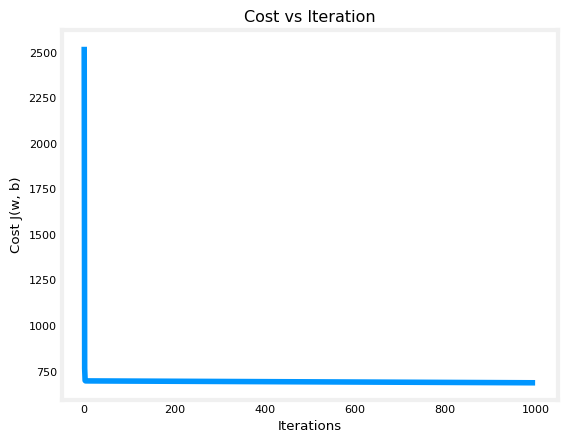

In [43]:
# let's plot to see how the cost function minimizes over the iterations
plt.plot([i for i in range(1000)], j_history, label='cost vs iterations')
plt.title("Cost vs Iteration")
plt.ylabel('Cost J(w, b)')
plt.xlabel('Iterations')
plt.show()

Based on the plot and the comparison b/w target and prediction values

- the cost function is declining as expected over the iterations
- the predicted value is not accurate (close to target)

In next lab, we will see how to improve this